In [29]:
# remember to reference Tim's code

In [ ]:
from Modules.brute_force_bond_finder import brute_force_bond_finder
from Modules.moebius_machinery import mat_vec_mu_graph
from Modules.next_closure_bond_finder import next_closure_bond_finder
import scipy
import numpy as np
import itertools
import networkx as nx
from Modules.moebius_machinery import mat_vec_solve_mu
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
import sys
sys.path.insert(0, '../szzoli-ite-in-python-44a8f15e2dc9')
from ite.cost.x_factory import co_factory


In [3]:
def covariance_matrix_bond_new(G, d, bond, rho):

    """
        Generates the covariance matrix actually respecting the factorisation structure of a given bond. Only fills in an entry of the
        covariance if the graph actually has an edge between these entries. d is the number of variables, rho is the correlation strength 
        between dependent variables
    """

    cov = np.zeros((d, d))

    # Loop over all blocks
    for block in bond:

        # Generate all pairs in the block
        if len(block) > 1:
            pairs = itertools.combinations(block, 2)

            # Fill in covariance matrix entries
            for u, v in pairs:
                if G.has_edge(u, v):
                    cov[u, v] = rho
                    cov[v, u] = rho

    for i in range(d):
        cov[i, i] = 1

    return cov

In [4]:
def restrict_new(G, sigma, bond, rho):

    """
        Restricts a known covariance matrix giving factorisation structure of a joint (Gaussian) distribution to give the covariance for
        factorisation restricted by some given bond
    """

    # Copy to prevent overwriting
    sigma_bond = sigma.copy()

    # Number of variables
    d = sigma.shape[0]

    # Update covariance to match bond factorisation structure
    for block in bond:
        for i in block:
            for j in range(d):
                if j not in block:
                    sigma_bond[i, j] = 0
                if j in block:
                    if G.has_edge(i, j):
                        sigma_bond[i, j] = rho

    return sigma_bond

In [15]:
def analytic_gaussian_bi_new(G, algo, sigma, rho, alpha=0.5):

    """
        G the graph, algo the bond-finding algorithm, sigma gives the factorisation structure of the joint, alpha the specified parameter for 
        the TA divergence (normally 0.5). This function calculates the analytic bond information for some graph G when the dataset is
        multivariate Gaussian that factorises according to the covariance matrix sigma
    """

    # Get bonds and moebius coefficients
    bonds = algo(G)
    d = len(bonds[0])
    _, _, mu = mat_vec_solve_mu(bonds)

    # Initialise running sum
    sum = 0.0

    # Main calculation loop
    for i, bond in enumerate(bonds):
        cov_pi = restrict_new(G, sigma, bond, rho)
        div = ((np.linalg.det(np.linalg.inv(cov_pi))) ** (alpha / 2)) / (np.linalg.det(alpha * np.linalg.inv(cov_pi) + (1 - alpha) * np.eye(cov_pi.shape[0]))) ** (1/2)
        sum += mu[i] * ((div - 1.0) / (alpha - 1.0))

    return sum

In [6]:
cost = 'BDTsallis_KnnK'
co = co_factory(cost, mult=True, alpha=0.5, k=5)

In [45]:
K_4 = nx.complete_graph(4)
P_4 = nx.path_graph(4)
C_4 = nx.cycle_graph(4)
bonds_K_4 = brute_force_bond_finder(K_4)
bonds_P_4 = brute_force_bond_finder(P_4)
bonds_C_4 = brute_force_bond_finder(C_4)
print(bonds_C_4)

K_4_list = []
P_4_list = []
C_4_list = []

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]


In [16]:
P_4 = nx.path_graph(4)

P_4_list = []
bonds_P_4 = brute_force_bond_finder(P_4)

print(len(bonds_P_4))

for bond in bonds_P_4:
    sigma = covariance_matrix_bond_new(P_4, 4, bond, 0.8)

    P_4_list.append(analytic_gaussian_bi_new(P_4, brute_force_bond_finder, sigma, 0.8))

for i in range(len(bonds_P_4)):
    print(bonds_P_4[i], P_4_list[i])

8
[[0], [1], [2], [3]] nan
[[0], [1], [2, 3]] nan
[[0], [1, 2], [3]] nan
[[0, 1], [2], [3]] nan
[[0], [1, 2, 3]] nan
[[0, 1], [2, 3]] nan
[[0, 1, 2], [3]] nan
[[0, 1, 2, 3]] nan


C:\Users\morit\AppData\Local\Temp\ipykernel_4924\4170829437.py:20: RuntimeWarning: invalid value encountered in scalar power
  div = ((np.linalg.det(np.linalg.inv(cov_pi))) ** (alpha / 2)) / (np.linalg.det(alpha * np.linalg.inv(cov_pi) + (1 - alpha) * np.eye(cov_pi.shape[0]))) ** (1/2)


In [48]:
C_5 = nx.cycle_graph(5)

C_3_list = []
bonds = brute_force_bond_finder(C_5)

for bond in bonds:
    sigma = covariance_matrix_bond(5, bond, 0.5)

    C_3_list.append(analytic_gaussian_bi(C_5, brute_force_bond_finder, sigma))

for i in range(len(bonds)):
    print(bonds[i], C_3_list[i])

[[0], [1], [2], [3], [4]] 0.0
[[0], [1], [2], [3, 4]] 0.0
[[0], [1], [2, 3], [4]] 0.0
[[0], [1, 2], [3], [4]] 0.0
[[0, 1], [2], [3], [4]] 0.0
[[1], [2], [3], [0, 4]] 0.0
[[0], [1], [2, 3, 4]] -0.07775086869219616
[[0], [1, 2], [3, 4]] 0.0
[[0], [1, 2, 3], [4]] -0.07775086869219616
[[0, 1], [2], [3, 4]] 0.0
[[0, 1], [2, 3], [4]] 0.0
[[0, 1, 2], [3], [4]] -0.07775086869219616
[[1], [2], [0, 3, 4]] -0.07775086869219616
[[1], [2, 3], [0, 4]] 0.0
[[1, 2], [3], [0, 4]] 0.0
[[2], [3], [0, 1, 4]] -0.07775086869219616
[[0], [1, 2, 3, 4]] -0.10191653929734046
[[0, 1], [2, 3, 4]] -0.07472826990100079
[[0, 1, 2], [3, 4]] -0.07472826990100079
[[0, 1, 2, 3], [4]] -0.10191653929734046
[[1], [0, 2, 3, 4]] -0.10191653929734046
[[1, 2], [0, 3, 4]] -0.07472826990100079
[[1, 2, 3], [0, 4]] -0.07472826990100079
[[2], [0, 1, 3, 4]] -0.10191653929734046
[[2, 3], [0, 1, 4]] -0.07472826990100079
[[3], [0, 1, 2, 4]] -0.10191653929734046
[[0, 1, 2, 3, 4]] -0.10463738973463799


In [49]:
W_4 = nx.wheel_graph(4)

W_3_list = []
bonds = brute_force_bond_finder(W_4)

for bond in bonds:
    sigma = covariance_matrix_bond(4, bond, 0.5)

    W_3_list.append(analytic_gaussian_bi(W_4, brute_force_bond_finder, sigma))

for i in range(len(bonds)):
    print(bonds[i], W_3_list[i])

[[0], [1], [2], [3]] 0.0
[[0], [1], [2, 3]] 0.0
[[0], [1, 2], [3]] 0.0
[[0], [2], [1, 3]] 0.0
[[0, 1], [2], [3]] 0.0
[[1], [0, 2], [3]] 0.0
[[1], [2], [0, 3]] 0.0
[[0], [1, 2, 3]] 0.0
[[0, 1], [2, 3]] 0.0
[[0, 1, 2], [3]] 0.0
[[0, 2], [1, 3]] 0.0
[[1], [0, 2, 3]] 0.0
[[1, 2], [0, 3]] 0.0
[[2], [0, 1, 3]] 0.0
[[0, 1, 2, 3]] 0.05885962043620885


In [ ]:
P_4 = nx.path_graph(4)
C_4 = nx.complete_graph(4)
bonds_P_4 = brute_force_bond_finder(P_4)
bonds_C_4 = brute_force_bond_finder(C_4) # all 4-element partitions

In [51]:
# Organise four-element partitions by whether they induce a bond in path graph P_4 or not

bondlist = []

for bond in bonds_P_4:
    bondlist.append(bond)

for bond in bonds_C_4:
    if bond not in bonds_P_4:
        bondlist.append(bond)


In [52]:
bond_information_list = []

for bond in bondlist:
    sigma = covariance_matrix_bond(4, bond, 0.8)

    bond_information_list.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))

for i in range(len(bonds_C_4)):
    print(bondlist[i] in bonds_P_4)
    print(bondlist[i], bond_information_list[i])



True
[[0], [1], [2], [3]] 0.0
True
[[0], [1], [2, 3]] 0.0
True
[[0], [1, 2], [3]] 0.0
True
[[0, 1], [2], [3]] 0.0
True
[[0], [1, 2, 3]] 0.0
True
[[0, 1], [2, 3]] 0.0
True
[[0, 1, 2], [3]] 0.0
True
[[0, 1, 2, 3]] 0.0012350903462494678
False
[[0], [2], [1, 3]] 0.0
False
[[1], [0, 2], [3]] 0.0
False
[[1], [2], [0, 3]] 0.30969149054296663
False
[[0, 2], [1, 3]] -0.04795440965736186
False
[[1], [0, 2, 3]] -0.030297906056894863
False
[[1, 2], [0, 3]] 0.26173708088560477
False
[[2], [0, 1, 3]] -0.030297906056894863


In [54]:
_, _, mu = mat_vec_solve_mu(bonds_P_4)
print(mu)

[-1.  1.  1.  1. -1. -1. -1.  1.]


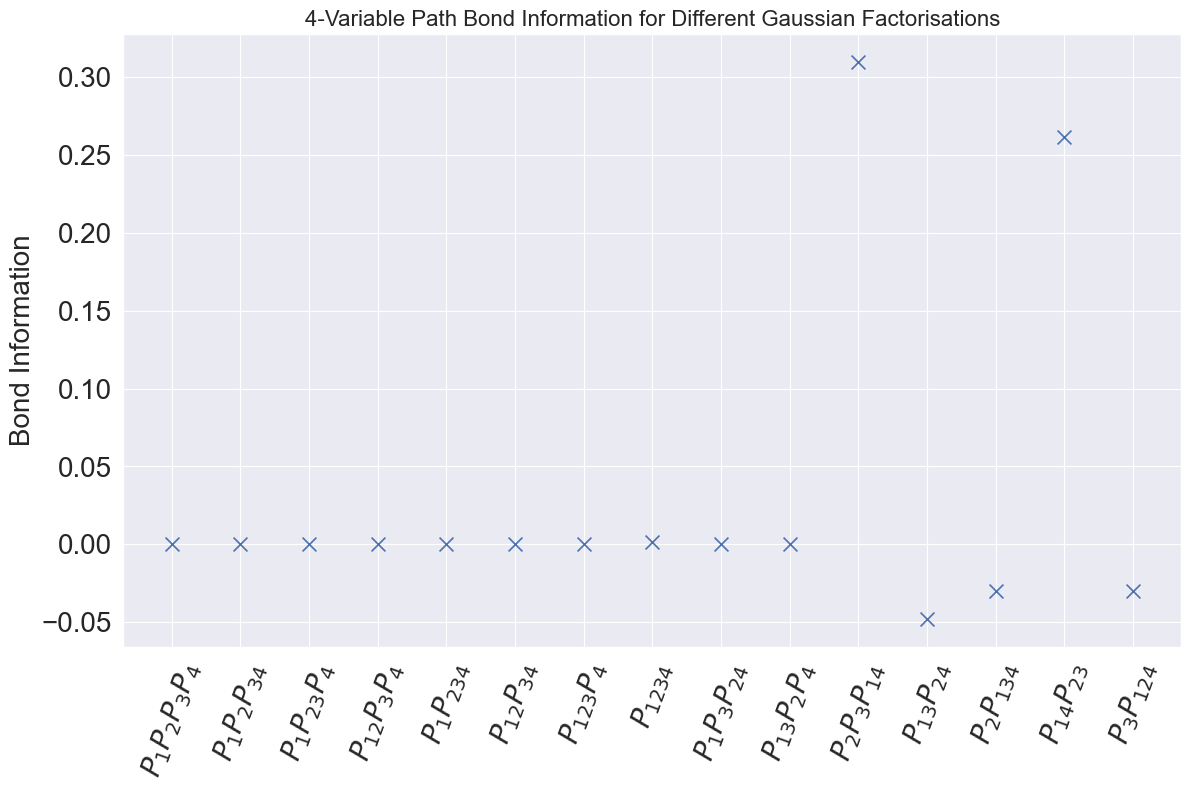

In [56]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot with matplotlib

x = range(15)

ax.scatter(x, bond_information_list, marker="x", s=100)

ax.set_xticks(x)

ax.set_xticklabels([
    r"$P_1P_2P_3P_4$",
    r"$P_1P_2P_{34}$",
    r"$P_1P_{23}P_4$",
    r"$P_{12}P_3P_4$",
    r"$P_1P_{234}$",
    r"$P_{12}P_{34}$",
    r"$P_{123}P_4$",
    r"$P_{1234}$",
    r"$P_1P_3P_{24}$",
    r"$P_{13}P_2P_4$",
    r"$P_2P_3P_{14}$",
    r"$P_{13}P_{24}$",
    r"$P_2P_{134}$",
    r"$P_{14}P_{23}$",
    r"$P_3P_{124}$",
], rotation=70)

# Customize with matplotlib
#ax.set_xlabel(r"Factorisation", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=20)
ax.tick_params(labelsize=20)
ax.set_title(r"4-Variable Path Bond Information for Different Gaussian Factorisations", fontsize=16)

plt.tight_layout()
plt.savefig(r"C:\Users\morit\Thesis_Repo\Plots\four_path_bi_gaussian.png")

In [57]:
sigma = covariance_matrix_bond(4, [[1], [0, 2], [3]], 0.8)
print(analytic_gaussian_bi_new(P_4, brute_force_bond_finder, sigma))

[[0], [1], [2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0], [1], [2, 3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0], [1, 2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0, 1], [2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0], [1, 2, 3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0, 1], [2, 3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0, 1, 2], [3]] [[1.  0.  0.8 0. ]
 [0.  1.  0.  0. ]
 [0.8 0.  1.  0. ]
 [0.  0.  0.  1. ]] -0.30969149054296663
[[0, 1, 2, 3]] [[1.  0.  0.8 0. ]
 [0.  1.  0.  0. ]
 [0.8 0.  1.  0. ]
 [0.  0.  0.  1. ]] 0.30969149054296663
0.0


In [58]:
sigma = covariance_matrix_bond(4, [[0], [2], [1, 3]], 0.8)
print(analytic_gaussian_bi_new(P_4, brute_force_bond_finder, sigma))

[[0], [1], [2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0], [1], [2, 3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0], [1, 2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0, 1], [2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] -0.0
[[0], [1, 2, 3]] [[1.  0.  0.  0. ]
 [0.  1.  0.  0.8]
 [0.  0.  1.  0. ]
 [0.  0.8 0.  1. ]] -0.30969149054296663
[[0, 1], [2, 3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0, 1, 2], [3]] [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 0.0
[[0, 1, 2, 3]] [[1.  0.  0.  0. ]
 [0.  1.  0.  0.8]
 [0.  0.  1.  0. ]
 [0.  0.8 0.  1. ]] 0.30969149054296663
0.0


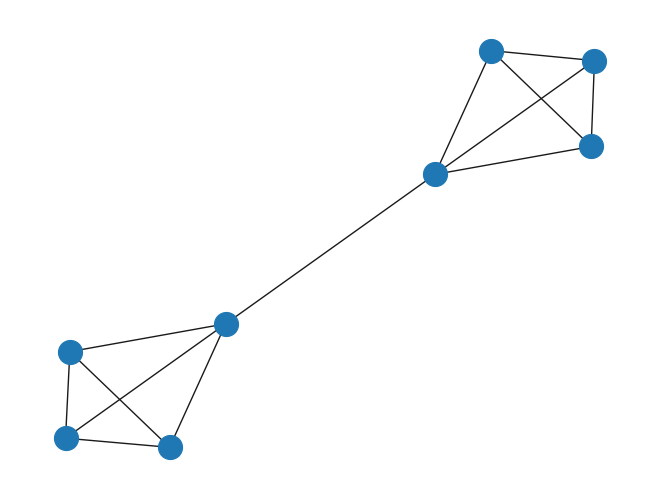

In [60]:
barbell_graph = nx.barbell_graph(4, 0)
nx.draw(barbell_graph)

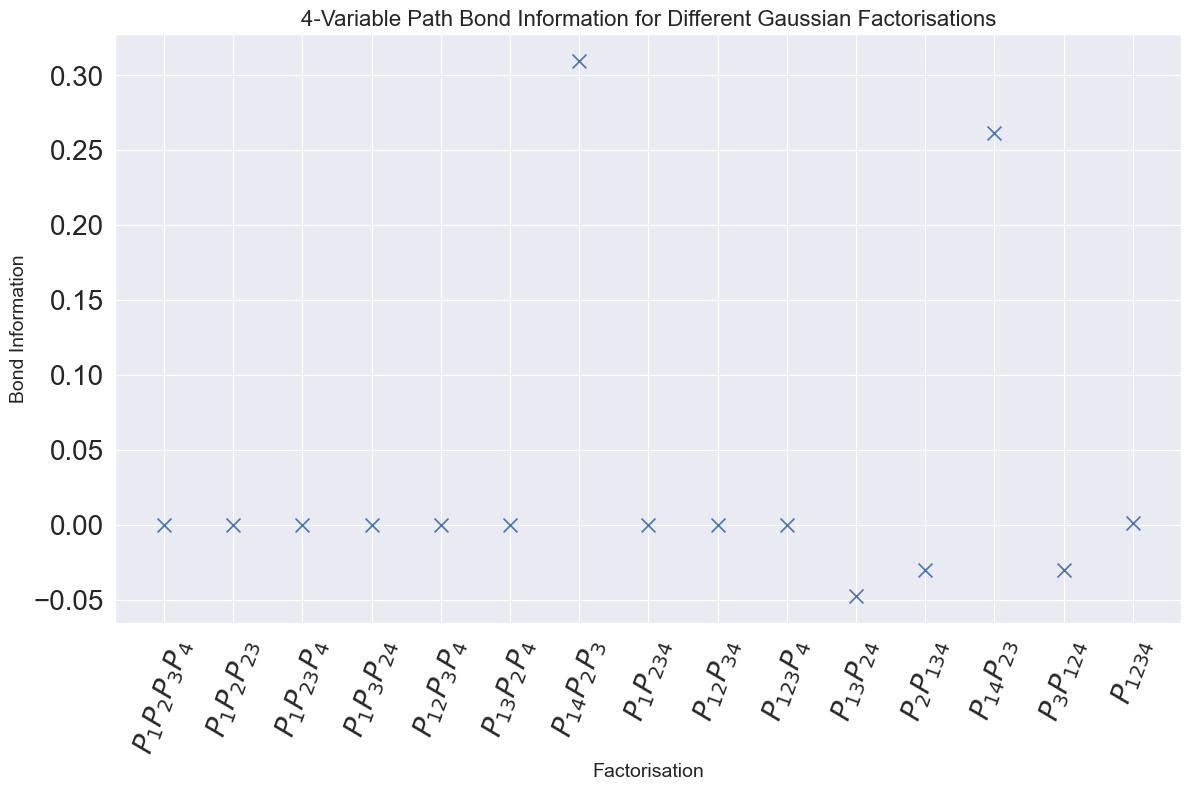

In [ ]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot with matplotlib

x = range(15)

ax.scatter(x, bond_information_list, marker="x", s=100)

ax.set_xticks(x)

ax.set_xticklabels([
    r"$P_1P_2P_3P_4$",
    r"$P_1P_2P_{{23}}$",
    r"$P_1P_{{23}}P_4$",
    r"$P_1P_3P_{{24}}$",
    r"$P_{{12}}P_3P_4$",
    r"$P_{{13}}P_2P_4$",
    r"$P_{{14}}P_2P_3$",
    r"$P_1P_{{234}}$",
    r"$P_{{12}}P_{{34}}$",
    r"$P_{{123}}P_4$",
    r"$P_{{13}}P_{{24}}$",
    r"$P_2P_{{134}}$",
    r"$P_{{14}}P_{{23}}$",
    r"$P_3P_{{124}}$",
    r"$P_{{1234}}$"
], rotation=70)

# Customize with matplotlib
ax.set_xlabel(r"Factorisation", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=14)
ax.tick_params(labelsize=20)
ax.set_title(r"4-Variable Path Bond Information for Different Gaussian Factorisations", fontsize=16)

plt.tight_layout()
plt.savefig(r"C:\Users\morit\Thesis_Repo\Plots\four_path_bi_gaussian.png")

In [ ]:
P_4 = nx.path_graph(4)
bonds = brute_force_bond_finder(P_4)
print(len(bonds))

bond_information_list = []

sigma = covariance_matrix_bond(4, [[1], [0, 2], [3]], 0.8)

print(analytic_gaussian_bi_new(P_4, brute_force_bond_finder, sigma))

8
0.0
-0.0
-0.0
-0.0
0.0
0.0
-0.30969149054296663
0.30969149054296663
0.0


In [ ]:
W_5 = nx.wheel_graph(5)
C_4 = nx.complete_graph(5)
bonds_C_4 = brute_force_bond_finder(C_4) # all 4-element partitions
print(brute_force_bond_finder(W_5))
print(len(bonds_C_4))

bond_information_list = []

for bond in bonds_C_4:
    sigma = covariance_matrix_bond(5, bond, 0.5)

    bond_information_list.append(analytic_gaussian_bi(W_5, brute_force_bond_finder, sigma))

for i in range(len(bonds_C_4)):
    print(bonds_C_4[i], bond_information_list[i])

[[[0], [1], [2], [3], [4]], [[0], [1], [2], [3, 4]], [[0], [1], [2, 3], [4]], [[0], [1, 2], [3], [4]], [[0], [2], [3], [1, 4]], [[0, 1], [2], [3], [4]], [[1], [0, 2], [3], [4]], [[1], [2], [0, 3], [4]], [[1], [2], [3], [0, 4]], [[0], [1], [2, 3, 4]], [[0], [1, 2], [3, 4]], [[0], [1, 2, 3], [4]], [[0], [2], [1, 3, 4]], [[0], [2, 3], [1, 4]], [[0], [3], [1, 2, 4]], [[0, 1], [2], [3, 4]], [[0, 1], [2, 3], [4]], [[0, 1, 2], [3], [4]], [[0, 2], [3], [1, 4]], [[1], [0, 2], [3, 4]], [[1], [0, 2, 3], [4]], [[1], [2], [0, 3, 4]], [[1], [2, 3], [0, 4]], [[1], [3], [0, 2, 4]], [[1, 2], [0, 3], [4]], [[1, 2], [3], [0, 4]], [[2], [0, 1, 3], [4]], [[2], [0, 3], [1, 4]], [[2], [3], [0, 1, 4]], [[0], [1, 2, 3, 4]], [[0, 1], [2, 3, 4]], [[0, 1, 2], [3, 4]], [[0, 1, 2, 3], [4]], [[0, 2], [1, 3, 4]], [[0, 2, 3], [1, 4]], [[0, 3], [1, 2, 4]], [[1], [0, 2, 3, 4]], [[1, 2], [0, 3, 4]], [[1, 2, 3], [0, 4]], [[2], [0, 1, 3, 4]], [[2, 3], [0, 1, 4]], [[3], [0, 1, 2, 4]], [[0, 1, 2, 3, 4]]]
52
[[0], [1], [2], [

ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

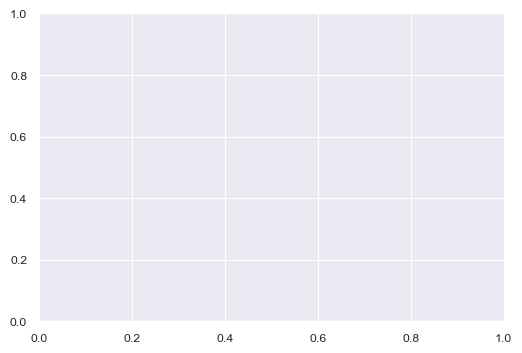

In [ ]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 4))

# Plot with matplotlib
ax.plot(np.arange(0, 1, 0.1), K_4_list,
        linewidth=2,
        markersize=5, label=r"Complete $K_4$")
ax.plot(np.arange(0, 1, 0.1), P_4_list,
        linewidth=2,
        markersize=5, label=r"Path $P_4$")
ax.plot(np.arange(0, 1, 0.1), C_4_list,
        linewidth=2,
        markersize=5, label=r"Cycle $C_4$")

# Customize with matplotlib
ax.set_xlabel(r"Correlation Strength $\rho$", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend()
ax.set_title(r"Bond Information for Factorisation $P_{13}P_{24}$", fontsize=16)

plt.tight_layout()
plt.savefig("figure.pdf", bbox_inches="tight")

In [ ]:
print(bonds_P_4)
print(bonds_C_4)

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[0, 1, 2, 3]]]
[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]


In [ ]:
K_4_list_2 = []
P_4_list_2 = []
C_4_list_2 = []

for rho in np.arange(0, 1, 0.1):
    sigma = covariance_matrix_bond(4, [[0], [1, 2, 3]], rho)


    #K_4_list_2.append(analytic_gaussian_bi(K_4, brute_force_bond_finder, sigma))
    P_4_list_2.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))
    #C_4_list_2.append(analytic_gaussian_bi(C_4, brute_force_bond_finder, sigma))

#print(K_4_list_2)
print(P_4_list_2)
#print(C_4_list_2)

0.0
-0.0
-0.0
-0.0
0.0
0.0
0.0
-0.0
0.0
0.0025204482082819
0.0025204482082819
-0.0
-0.006911358986639415
-0.0025204482082819
-0.0025204482082819
0.006911358986639415
0.0
0.01033387185996415
0.01033387185996415
-0.0
-0.026333064051241584
-0.01033387185996415
-0.01033387185996415
0.026333064051241584
0.0
0.024250136029404068
0.024250136029404068
-0.0
-0.05813779302867483
-0.024250136029404068
-0.024250136029404068
0.05813779302867483
0.0
0.045821635794248916
0.045821635794248916
-0.0
-0.10429942287167582
-0.045821635794248916
-0.045821635794248916
0.10429942287167582
0.0
0.07775086869219616
0.07775086869219616
-0.0
-0.16909587208256216
-0.07775086869219616
-0.07775086869219616
0.16909587208256216
0.0
0.12477107624601813
0.12477107624601813
-0.0
-0.2601667348129906
-0.12477107624601813
-0.12477107624601813
0.2601667348129906
0.0
0.1957405978576794
0.1957405978576794
-0.0
-0.39118681772754726
-0.1957405978576794
-0.1957405978576794
0.39118681772754726
0.0
0.30969149054296663
0.309691490542

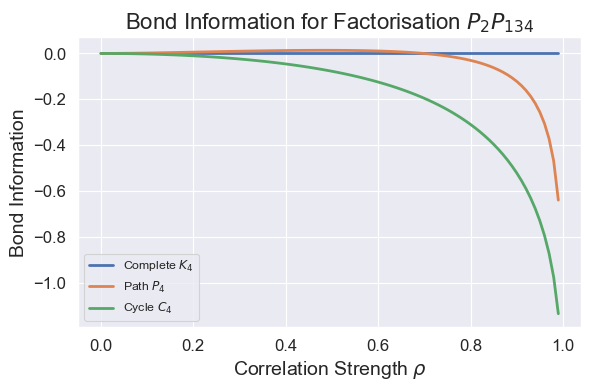

In [ ]:
# Set the overall style once
sns.set_theme(style="darkgrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 4))

# Plot with matplotlib
ax.plot(np.arange(0, 1, 0.01), K_4_list_2,
        linewidth=2,
        markersize=5, label=r"Complete $K_4$")
ax.plot(np.arange(0, 1, 0.01), P_4_list_2,
        linewidth=2,
        markersize=5, label=r"Path $P_4$")
ax.plot(np.arange(0, 1, 0.01), C_4_list_2,
        linewidth=2,
        markersize=5, label=r"Cycle $C_4$")

# Customize with matplotlib
ax.set_xlabel(r"Correlation Strength $\rho$", fontsize=14)
ax.set_ylabel("Bond Information", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend()
ax.set_title(r"Bond Information for Factorisation $P_{2}P_{134}$", fontsize=16)

plt.tight_layout()
plt.savefig("figure.pdf", bbox_inches="tight")

In [ ]:
C_4_list_3 = []

bonds = brute_force_bond_finder(C_4)
for bond in bonds:
    sigma = covariance_matrix_bond(4, bond, 0.5)
    C_4_list_3.append(analytic_gaussian_bi(C_4, brute_force_bond_finder, sigma))

print(bonds)
print(C_4_list_3)

[[[0], [1], [2], [3]], [[0], [1], [2, 3]], [[0], [1, 2], [3]], [[0, 1], [2], [3]], [[1], [2], [0, 3]], [[0], [1, 2, 3]], [[0, 1], [2, 3]], [[0, 1, 2], [3]], [[1], [0, 2, 3]], [[1, 2], [0, 3]], [[2], [0, 1, 3]], [[0, 1, 2, 3]]]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(-0.07775086869219616), np.float64(0.0), np.float64(-0.07775086869219616), np.float64(-0.09966471573937885)]


In [ ]:
# Issues with k too large

cost = 'BDTsallis_KnnK'
co = co_factory(cost, mult=True, alpha=0.5, k=30)

In [ ]:
# Making Streitberg
K_4 = nx.complete_graph(4)
bonds = brute_force_bond_finder(K_4)
cov = covariance_matrix_bond(4, [[0, 2], [1, 3]], 0.5)

P_4 = nx.path_graph(4)
print(bonds[-1])

[[0, 1, 2, 3]]


In [ ]:
print("Path-induced bond information:")
print(bond_information(P_4, generate_gaussian(cov, 500), co.estimation, brute_force_bond_finder))
print("Completegraph-induced bond information (streitberg):")
print(bond_information(K_4, generate_gaussian(cov, 500), co.estimation, brute_force_bond_finder))

Path-induced bond information:
-0.02413269558765685
Completegraph-induced bond information (streitberg):
-0.09139899426433762


In [ ]:
K_3 = nx.complete_graph(3)
bonds = brute_force_bond_finder(K_3)
cov = covariance_matrix_bond(3, bonds[2], 0.5)

for n in [500, 1000, 2000, 5000]:
    results = [bond_information(K_3, generate_gaussian(cov, n), co.estimation, brute_force_bond_finder) 
               for _ in range(100)]
    print(f"n={n}: mean={np.mean(results):.4f}, |mean|={abs(np.mean(results)):.4f}")

n=500: mean=0.0138, |mean|=0.0138
n=1000: mean=0.0141, |mean|=0.0141


c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:188: SyntaxWarning: invalid escape sequence '\i'
  as \int p^{1/2}(x)q^{1/2}(x)dx = \int p^{-1/2}(x)q^{1/2}(x)
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:339: SyntaxWarning: invalid escape sequence '\i'
  divergence as \int p^2(x)q^{-1}(x)dx - 1 =
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\cost\base_d.py:435: SyntaxWarning: invalid escape sequence '\i'
  divergence as \int p^{1/2}(x)q^{1/2}(x)dx =
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\shared.py:150: SyntaxWarning: invalid escape sequence '\i'
  """ Estimate i_alpha = \int p^{\alpha}(y)dy.
c:\Users\morit\Thesis_Repo\Notebooks\../szzoli-ite-in-python-44a8f15e2dc9\ite\shared.py:232: SyntaxWarning: invalid escape sequence '\i'
  """ Estimate d_temp1 = \int p^{\alpha}(u)q^{1-\alpha}(u)du.
c:\Users\morit\Thesis_Repo\Notebooks\.

KeyboardInterrupt: 

## GMRF-based graph-respecting covariance (fixes NaNs from `covariance_matrix_bond_new`)

`covariance_matrix_bond_new` / `restrict_new` above produce NaN bond information because they fill correlation
values directly into the covariance matrix along graph edges. For a block spanning 3+ path-connected
variables this is not guaranteed to be positive semi-definite (e.g. a 3-node chain with edge correlation
`rho=0.8` has a negative eigenvalue), so `det(inv(cov_pi))` goes negative and raising it to a fractional
power gives NaN.

Instead, build the graph structure into the **precision matrix** (inverse covariance): put `-rho` at graph
edges within a block and make the diagonal dominant (`1 + sum of |off-diagonal| in the row`). By the
Gershgorin circle theorem this is guaranteed positive definite for any `rho`, so inverting it always gives a
valid covariance matrix whose zero pattern in the precision matrix encodes conditional independence
respecting the graph (a standard Gaussian Markov Random Field construction). The existing `restrict` /
`analytic_gaussian_bi` from `gaussian_testing.py` can then be reused unchanged, since they just zero
cross-block covariance entries and don't need modification.

In [17]:
from Modules.gaussian_testing import restrict, analytic_gaussian_bi

def precision_matrix_bond(G, d, bond, rho):

    """
        Builds a precision matrix (inverse covariance) whose zero pattern encodes the conditional independence
        structure induced by graph G restricted to a given bond: only entries corresponding to actual edges of
        G within the same block are filled in with -rho. The diagonal is set to be strictly diagonally dominant,
        which guarantees (Gershgorin) that the matrix is positive definite for any rho.
    """

    omega = np.zeros((d, d))

    for block in bond:
        for u, v in itertools.combinations(block, 2):
            if G.has_edge(u, v):
                omega[u, v] = -rho
                omega[v, u] = -rho

    for i in range(d):
        omega[i, i] = 1 + np.sum(np.abs(omega[i, :]))

    return omega

def covariance_matrix_bond_gmrf(G, d, bond, rho):

    """
        Covariance matrix obtained by inverting a graph-respecting precision matrix. Always positive definite,
        unlike covariance_matrix_bond_new which can produce invalid (non-PSD) covariance matrices.
    """

    omega = precision_matrix_bond(G, d, bond, rho)

    return np.linalg.inv(omega)

In [19]:
P_5 = nx.path_graph(5)
bonds_P_5 = brute_force_bond_finder(P_5)

P_5_list_gmrf = []

for bond in bonds_P_5:
    sigma = covariance_matrix_bond_gmrf(P_5, 5, bond, 0.8)
    P_5_list_gmrf.append(analytic_gaussian_bi(P_5, brute_force_bond_finder, sigma))

for i in range(len(bonds_P_5)):
    print(bonds_P_5[i], P_5_list_gmrf[i])

[[0], [1], [2], [3], [4]] 0.0
[[0], [1], [2], [3, 4]] 0.0
[[0], [1], [2, 3], [4]] 0.0
[[0], [1, 2], [3], [4]] 0.0
[[0, 1], [2], [3], [4]] 0.0
[[0], [1], [2, 3, 4]] 0.0
[[0], [1, 2], [3, 4]] 0.0
[[0], [1, 2, 3], [4]] 0.0
[[0, 1], [2], [3, 4]] 0.0
[[0, 1], [2, 3], [4]] 0.0
[[0, 1, 2], [3], [4]] 0.0
[[0], [1, 2, 3, 4]] 0.0
[[0, 1], [2, 3, 4]] 0.0
[[0, 1, 2], [3, 4]] 0.0
[[0, 1, 2, 3], [4]] 0.0
[[0, 1, 2, 3, 4]] -4.765591981481521e-06


In [20]:
# Generate bonds for P_4 and all 4-element partitions (bonds for complete graph K_4)

P_4 = nx.path_graph(4)
K_4 = nx.complete_graph(4)
bonds_P_4 = brute_force_bond_finder(P_4)
partitions = brute_force_bond_finder(K_4) # all 4-element partitions

# Organise four-element partitions by whether they are a bond in path graph P_4 or not

# Initiate list with all the bonds of P_4
bondlist = [bond for bond in bonds_P_4]

# Now append non-bond partitions
for bond in partitions:
    if bond not in bonds_P_4:
        bondlist.append(bond)


In [24]:
# Calculate bond information for all of the different factorisations of the joint Gaussian distribution

bond_information_list = []

# Calculate for all 4-element partitions, bond or non-bond
for bond in bondlist:

    # Covariance to induce joint factorisation according to current bond. Correlation strength between independent variables 0.8
    sigma = covariance_matrix_bond_gmrf(P_4, 4, bond, 0.8)

    # Calculate and append
    bond_information_list.append(analytic_gaussian_bi(P_4, brute_force_bond_finder, sigma))

# This part was used to identify which non-bond partitions the bond information was vanishing for
for i in range(len(bondlist)):
    print(bondlist[i] in bonds_P_4)
    print(bondlist[i], bond_information_list[i])



True
[[0], [1], [2], [3]] 0.0
True
[[0], [1], [2, 3]] 0.0
True
[[0], [1, 2], [3]] 0.0
True
[[0, 1], [2], [3]] 0.0
True
[[0], [1, 2, 3]] 0.0
True
[[0, 1], [2, 3]] 0.0
True
[[0, 1, 2], [3]] 0.0
True
[[0, 1, 2, 3]] 2.7102056260774887e-05
False
[[0], [2], [1, 3]] 0.0
False
[[1], [0, 2], [3]] 0.0
False
[[1], [2], [0, 3]] 0.0
False
[[0, 2], [1, 3]] 0.0
False
[[1], [0, 2, 3]] 0.0
False
[[1, 2], [0, 3]] 0.0
False
[[2], [0, 1, 3]] 0.0


In [ ]:
def restrict_bond_meet(G, sigma, bond):
    """
    Drop-in replacement for restrict(sigma, bond) that indexes each term by the
    bond-lattice meet instead of the partition-lattice meet: a correlation on (i, j)
    survives only if i and j lie in the same G-connected component of their meet-block.
    Reads 'same tau-block' from sigma's nonzero pattern, so it assumes sigma was built
    by covariance_matrix_bond (all within-block pairs correlated).
    """
    out = np.zeros_like(sigma)
    np.fill_diagonal(out, np.diag(sigma))
    for block in bond:                       # a pi-block
        block = list(block)
        H = nx.Graph(); H.add_nodes_from(block)
        for u, v in itertools.combinations(block, 2):
            if sigma[u, v] != 0 and G.has_edge(u, v):   # same tau-block AND a real edge
                H.add_edge(u, v)
        for comp in nx.connected_components(H):          # bond-meet blocks
            comp = list(comp)
            for u, v in itertools.combinations(comp, 2):
                out[u, v] = sigma[u, v]
                out[v, u] = sigma[v, u]
    return out